In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import GPT2Model, GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2Model.from_pretrained("gpt2",
                                   output_attentions=True,
                                   output_hidden_states=True)
model.eval()

print("Ready!")

c:\Users\devuser3\AppData\Roaming\uv\python\cpython-3.14.3-windows-x86_64-none\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 5653.78it/s]

Ready!


In [2]:
text = "The king and queen ruled the kingdom with power"
inputs = tokenizer(text, return_tensors="pt")
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

# Attention output hooks
attn_outputs = {}

def make_hook(layer_idx):
    def hook(module, input, output):
        attn_outputs[layer_idx] = output[0].detach()
    return hook

hooks = []
for i in range(12):
    h = model.h[i].attn.register_forward_hook(make_hook(i))
    hooks.append(h)

with torch.no_grad():
    outputs = model(**inputs)

for h in hooks:
    h.remove()


print(f"{'Layer':<8} {'Attn Output Norm':<20} {'Mean':<10} {'Std'}")
print("-"*50)

for i in range(12):
    attn_out = attn_outputs[i][0]  # [n_tokens, 768]
    norm = attn_out.norm().item()
    mean = attn_out.mean().item()
    std  = attn_out.std().item()
    print(f"L{i+1:<7} {norm:<20.4f} {mean:<10.4f} {std:.4f}")

Layer    Attn Output Norm     Mean       Std
--------------------------------------------------
L1       91.7775              0.0114     1.1039
L2       45.7352              -0.0101    0.5501
L3       23.6828              -0.0048    0.2848
L4       24.9808              -0.0000    0.3005
L5       28.8454              -0.0006    0.3470
L6       25.2780              0.0004     0.3041
L7       29.2138              0.0053     0.3514
L8       31.9976              0.0090     0.3848
L9       45.4068              0.0026     0.5462
L10      43.6276              0.0079     0.5247
L11      63.1645              0.0077     0.7598
L12      2724.9026            -0.7206    32.7700


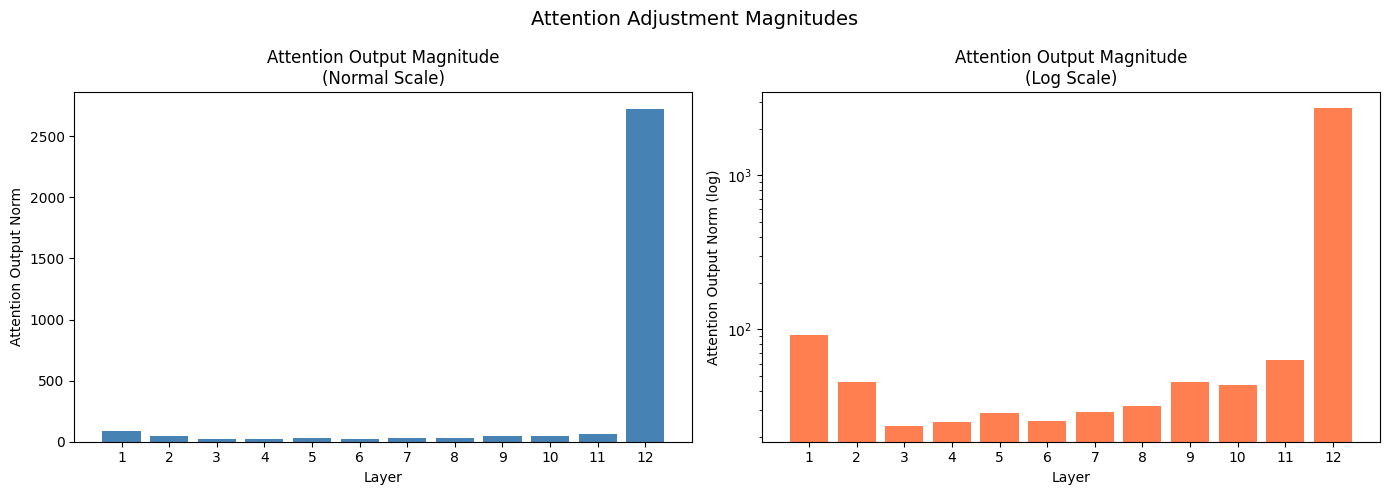

In [3]:
norms = [attn_outputs[i][0].norm().item() for i in range(12)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


axes[0].bar(range(1, 13), norms, color="steelblue")
axes[0].set_xlabel("Layer")
axes[0].set_ylabel("Attention Output Norm")
axes[0].set_title("Attention Output Magnitude\n(Normal Scale)")
axes[0].set_xticks(range(1, 13))


axes[1].bar(range(1, 13), norms, color="coral")
axes[1].set_xlabel("Layer")
axes[1].set_ylabel("Attention Output Norm (log)")
axes[1].set_title("Attention Output Magnitude\n(Log Scale)")
axes[1].set_xticks(range(1, 13))
axes[1].set_yscale("log")

plt.suptitle("Attention Adjustment Magnitudes", fontsize=14)
plt.tight_layout()
plt.show()

* Layer 1 has the largest attention output (early processing)
* Layer 3 has the smallest (minimal adjustment)
* Layer 12 shows an explosion — 2724! It prepares the final output
* Log scale reveals the pattern more clearly
